# Induktīvi turpināmu konstrukciju meklēšana

Vairāki perfekto polimondu virkņu konstruēšanas uzdevumi paredz atfiltrēt tādus polimondus, kam virzienu burtu virknīti var sadalīt vairākos fragmentos tā, lai tur (atbilstoši mums zināmo induktīvo konstrukciju soļiem) varētu iespraust jaunus fragmentus. Šajā "notebook" apskatīsim vairākus piemērus:  

* Nulles virkņu meklēšana -- t.i. tādas polimondos sastopamas virknes $x$, kam $p(x) = (0,0,0)$. 
* Virknes $uvwxy$, kur $v$ un $x$ varētu iespraust ar bezkonteksta gramatiku ($uvwxy$, $uv^2wx^2y$, $uv^3wx^3y$, $\ldots$). Šādas virknes noteikti apmierina nosacījumu $p(x) = 3p(v)$ un vēl divus citus lineārus vienādojumus. 
* Virknes, kur divos dažādos veidos var veikt pāreju $x \rightarrow x + 6$.

**1. piemērs:**
  Virzienu vektoru definīcijas, piemērs ar parasto summu $p(\mathtt{ABCDEF})$ un dilstošo summu $g(\mathtt{ABCDEF})$. 

In [1]:
from polyforms.inductive_splits import InductiveSplits
from polyforms.point_tg import PointTg, DIRECTIONS

print('p(ABCDEF) = {}'.format(InductiveSplits.p('ABCDEF')))
print('g(ABCDEF) = {}'.format(InductiveSplits.g('ABCDEF')))

directions = ['A', 'B', 'C', 'D', 'E', 'F']
for dir in directions: 
    print('{} -> {}'.format(dir, DIRECTIONS[dir]))

p(ABCDEF) = (0,0,0)
g(ABCDEF) = (6,-6,0)
A -> (1,0,-1)
B -> (1,-1,0)
C -> (0,-1,1)
D -> (-1,0,1)
E -> (-1,1,0)
F -> (0,1,-1)


**2.piemērs:** Uzzīmēt tabuliņu ar dažām parastās summas un dilstošās sumas vērtībām. 

In [2]:
from tabulate import tabulate
from IPython.display import display, Markdown

words = ['ACEDF', 'ABCDEF', 'ACDEFAC', 'ACDEFBF', 'ACECEAEAC']

# Prepare data
data = [[f'`{w}`', InductiveSplits.p(w), InductiveSplits.g(w)] for w in words]

# Define headers
headers = ['$w$', '$p(w)$', '$g(w)$']

# Create table
table = tabulate(data, headers, tablefmt="pipe")

# Print the table
# print(table)
display(Markdown(table))

ModuleNotFoundError: No module named 'tabulate'

**3. piemērs:** Parāda tos 13-polimondus, kuriem $p(x) = (0,0,0)$, t.i. visiem virzienu burtiem atbilstošā vienības vektoru summa ir nulles vektors. Tas ir filtrēšanas uzdevuma piemērs; nav nekas zināms par polimondiem, kuru virzienu vektori veido nulles virkni.

In [3]:
ind_split = InductiveSplits(source = 'perfect_13.txt')
sequences = ind_split.read_list()
print(f'13-polimondu kopskaits: {len(sequences)}')
results = []
for seq in sequences: 
    if InductiveSplits.p(seq) == PointTg(0,0,0):
        results.append(seq)
results_count = len(results)
print(f'13-polimondu skaits, kam p(x) = (0,0,0) -- kopskaits ir {results_count}')
for j in range(results_count//4):
    print(results[4*j:4*j+4])
if results_count % 4 != 0: 
    print(results[4*(results_count//4):])
    


13-polimondu kopskaits: 228
13-polimondu skaits, kam p(x) = (0,0,0) -- kopskaits ir 16
['ABCDEFDEAFBDB', 'ABCDFDEFDFABC', 'ABCDFDFEDFACB', 'ABCECEFEDFACB']
['ABDBDEFEDFACB', 'ABDCEAEDEFABC', 'ABDCEAEDFEACB', 'ABFDEDCECABAE']
['ABFEDCECDBFBF', 'ACACDEFEDFACB', 'ACACEDFDEFACB', 'ACBDFDEFEABDB']
['ACBDFDEFEACAC', 'ACBDFDFEDFABC', 'ACBDFEDEAFBDB', 'ACDCEAEFAFBDC']


<Figure size 432x288 with 0 Axes>

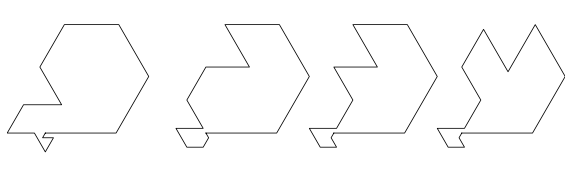

<Figure size 432x288 with 0 Axes>

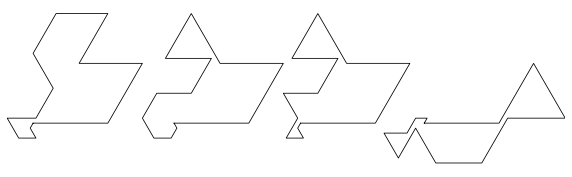

<Figure size 432x288 with 0 Axes>

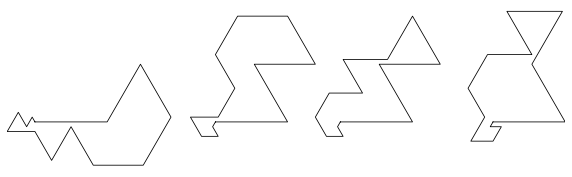

<Figure size 432x288 with 0 Axes>

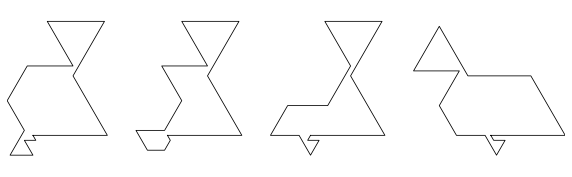

In [4]:
from polyforms.draw_scene import *
from polyforms.perfect_seq import *
from polyforms.polyiamond import Polyiamond
from polyforms.point_tg import *
import numpy as np

offsets = [0, 5, 5, 5, 0, 0, 0, -10,  0, 10, 10, 20,  0, 5, 10, 15]
polygons = [Polyiamond(s) for s in results]

for j in range(0,4):
    scene = DrawScene(Align.BASELINE)
    for i in range(4*j,4*j+4):
        scene.add_polyiamond(f'p{i}', polygons[i], (offsets[i], 0))
    scene.pack()
    scene.set_size_in(10,3)

<Figure size 432x288 with 0 Axes>

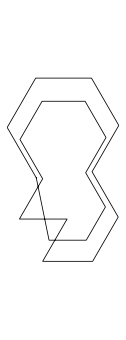

In [5]:
scene = DrawScene(Align.BASELINE)

S = 'CBAFEFEDBDBCBAFEFEDB'
sides = list(zip(range(50, 50-len(S), -1), list(S)))
p = Polyiamond(sides)
scene.add_polyiamond('p', p)
scene.pack()
scene.set_size_in(2,6)

<Figure size 432x288 with 0 Axes>

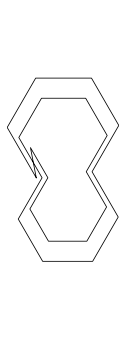

In [11]:
scene = DrawScene(Align.BASELINE)

S = 'CBAFEFEDCBCBAFEFEDCBCB'
sides = list(zip(range(50, 50-len(S), -1), list(S)))
p = Polyiamond(sides)
scene.add_polyiamond('p', p)
scene.pack()
scene.set_size_in(2,6)

In [6]:
result = Polyiamond.find_fragments_cfg('ABCDEFDEAFBDB')
# for kk,vv in result.items():
#    print('{}: {}'.format(kk,vv))
print(result)

[]


In [7]:
from polyforms.inductive_splits import InductiveSplits

import copy as cp
from polyforms.polyiamond import Polyiamond

splits = InductiveSplits('perfect_15.txt')
all_sides = splits.read_list()
all_results15 = []
for sides in all_sides:
    result = Polyiamond.find_fragments_cfg(sides)
    if result != []:
        all_results15.append(result)
print(all_results15)

flat_results15 = [item for sublist in all_results15 for item in sublist]


print(flat_results15)
    
vals = []
isValid = []
for result in flat_results15:
    result = list(result)
    p1 = ''.join(result)
    v,x = result[1], result[-2]
    result2 = cp.copy(result)
    result2.insert(1,v)
    result2.insert(-1,x)
    p2 = ''.join(result2)
    result3 = cp.copy(result2)
    result3.insert(1,v)
    result3.insert(-1,x)
    p3 = ''.join(result3)
    vals.append((p1,p2,p3))
    poly = Polyiamond(p3)
    isValid.append(poly.is_valid())
    
# print(vals)
print(isValid)


[[('AC', 'ABCE', 'DEF', 'EDEF', 'AC'), ('AC', 'ABCE', 'DE', 'FEDE', 'FAC'), ('AC', 'ABCE', 'D', 'EFED', 'EFAC'), ('AC', 'ABCE', '', 'DEFE', 'DEFAC')], [('AC', 'ABCE', 'DE', 'FEDE', 'FBF'), ('AC', 'ABCE', 'D', 'EFED', 'EFBF'), ('AC', 'ABCE', '', 'DEFE', 'DEFBF')], [('AC', 'AFEC', 'EFD', 'CDCB', 'CB'), ('A', 'CAFE', 'CEFD', 'CDCB', 'CB')]]
[('AC', 'ABCE', 'DEF', 'EDEF', 'AC'), ('AC', 'ABCE', 'DE', 'FEDE', 'FAC'), ('AC', 'ABCE', 'D', 'EFED', 'EFAC'), ('AC', 'ABCE', '', 'DEFE', 'DEFAC'), ('AC', 'ABCE', 'DE', 'FEDE', 'FBF'), ('AC', 'ABCE', 'D', 'EFED', 'EFBF'), ('AC', 'ABCE', '', 'DEFE', 'DEFBF'), ('AC', 'AFEC', 'EFD', 'CDCB', 'CB'), ('A', 'CAFE', 'CEFD', 'CDCB', 'CB')]
[False, False, False, False, False, False, False, False, False]


In [14]:
from polyforms.inductive_splits import InductiveSplits

splits = InductiveSplits('perfect_19.txt')
all_sides = splits.read_list()
all_results = []
for sides in all_sides:
    result = Polyiamond.find_fragments_cfg(sides)
    if result != []:
        all_results.append(result)
print(all_results)

flat_results = [item for sublist in all_results for item in sublist]


print(flat_results)
    
vals = []
isValid = []
for result in flat_results:
    result = list(result)
    p1 = ''.join(result)
    v,x = result[1], result[-2]
    result2 = cp.copy(result)
    result2.insert(1,v)
    result2.insert(-1,x)
    p2 = ''.join(result2)
    result3 = cp.copy(result2)
    result3.insert(1,v)
    result3.insert(-1,x)
    p3 = ''.join(result3)
    vals.append((p1,p2,p3))
    poly = Polyiamond(p3)
    isValid.append(poly.is_valid())
    
# print(vals)
print(isValid)

for idx,myvalid in enumerate(isValid):
    if myvalid:
        print((flat_results[idx][1],flat_results[idx][3]))

[[('AB', 'ABCE', 'DEC', 'EDEF', 'AEDEAF')], [('AB', 'ABCE', 'DEC', 'EDEF', 'AFDEDE')], [('AB', 'ACEC', 'BDEDEFDF', 'EFAF', 'E'), ('AB', 'ACEC', 'BDEDEFD', 'FEFA', 'FE')], [('AB', 'ACEC', 'DEAECED', 'FEFA', 'BC')], [('A', 'BACECEA', 'EC', 'DEDFEFB', 'DB'), ('', 'ABACECE', 'AEC', 'DEDFEFB', 'DB')], [('AB', 'ACEC', 'EDBDFED', 'FEFA', 'BF')], [('', 'ABAECE', 'FEC', 'BDECED', 'BCAC')], [('', 'ABAECE', 'FEC', 'BDECED', 'BCBF')], [('', 'ABAEDE', 'FE', 'CECBDB', 'CBCAC')], [('', 'ABAEDE', 'FE', 'CECBDB', 'CBCBF')], [('', 'ABAEDE', 'FE', 'DBDCAC', 'BCBDC')], [('A', 'BAFD', 'EFDBC', 'DEDC', 'DBCAE'), ('A', 'BAFD', 'EFDB', 'CDED', 'CDBCAE')], [('A', 'BAFD', 'EFDBC', 'DEDC', 'DCBAF'), ('A', 'BAFD', 'EFDB', 'CDED', 'CDCBAF')], [('A', 'BAFD', 'EFDCB', 'DEDC', 'DBCAF')], [('A', 'BAFD', 'FDECB', 'DEDC', 'DCABF')], [('A', 'BAFD', 'FEDBC', 'DEDC', 'DCBAE'), ('A', 'BAFD', 'FEDB', 'CDED', 'CDCBAE')], [('A', 'BAFD', 'FEDBC', 'DEDC', 'DCBFB'), ('A', 'BAFD', 'FEDB', 'CDED', 'CDCBFB')], [('A', 'BAFD', 'FEDCB'

[False, False, True, True, True, False, False, True, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, True, True, True, False, False, False, True, False, False, False, False, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, F

<Figure size 432x288 with 0 Axes>

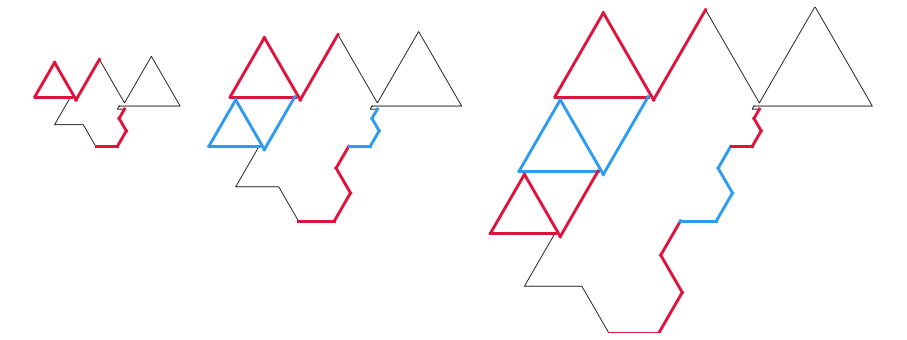

In [15]:
#('ACEC', 'ECEA', 'EAF', 'ABCB', 'DB')
pp = ['ACECECEAEAFABCBDB', 'ACECECEAECEAEAFABCBABCBDB', 'ACECECEAECEAECEAEAFABCBABCBABCBDB']
scene3 = DrawScene(Align.BASELINE)
for idx,p in enumerate(pp): 
    scene3.add_polyiamond('p{}'.format(idx), Polyiamond(p))
    # print('{}, {}'.format(idx, p.sides))
    
scene3.pack()

scene3.highlight('p0', [4, 5, 6, 7], '#DC143C')
scene3.highlight('p0', [11, 12, 13, 14], '#DC143C')


scene3.highlight('p1', [4, 5, 6, 7], '#DC143C')
scene3.highlight('p1', [8, 9, 10, 11], '#2D9BF0')
scene3.highlight('p1', [15, 16, 17, 18], '#DC143C')
scene3.highlight('p1', [19, 20, 21, 22], '#2D9BF0')

scene3.highlight('p2', [4, 5, 6, 7], '#DC143C')
scene3.highlight('p2', [8, 9, 10, 11], '#2D9BF0')
scene3.highlight('p2', [12, 13, 14, 15], '#DC143C')
scene3.highlight('p2', [19, 20, 21, 22], '#DC143C')
scene3.highlight('p2', [23, 24, 25, 26], '#2D9BF0')
scene3.highlight('p2', [27, 28, 29, 30], '#DC143C')

scene3.set_size_in(16,6)

<Figure size 432x288 with 0 Axes>

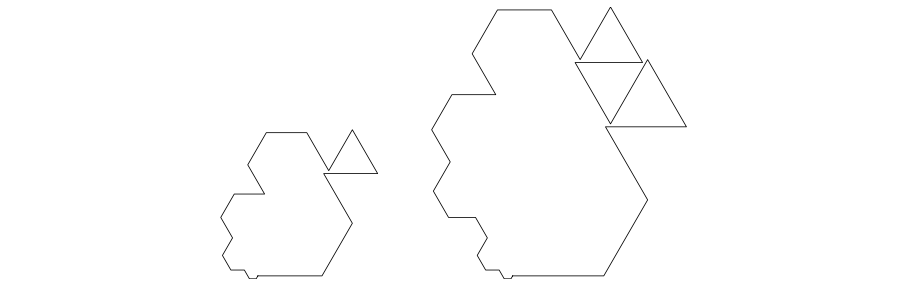

In [ ]:
# ('AB', 'CAEA', 'FDE', 'DEDC', 'DCDC')
pp = ['ABCAEAFDEDEDCDCDC', 'ABCAEACAEAFDEDEDCDEDCDCDC', 'ABCAEACAEACAEAFDEDEDCDEDCDEDCDCDC']

scene3 = DrawScene(Align.BASELINE)
for idx,p in enumerate(pp): 
    scene3.add_polyiamond('p{}'.format(idx), Polyiamond(p))
scene3.pack()
scene3.set_size_in(16,5)

<Figure size 432x288 with 0 Axes>

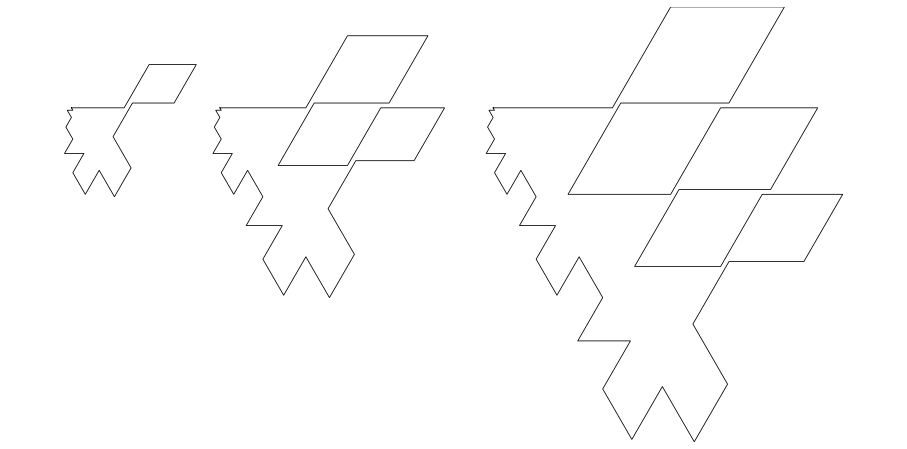

In [9]:
ss = ['ABAEDEFECECBDBCBCAC', 'ABAEDEABAEDEFECECBDBCECBDBCBCAC', 'ABAEDEABAEDEABAEDEFECECBDBCECBDBCECBDBCBCAC']

offsets = [0, -30, -60]

scene = DrawScene(Align.BASELINE)
for idx,p in enumerate(ss):
    scene.add_polyiamond('p{}'.format(idx), Polyiamond(p), (offsets[idx], 0))
    # print('{}, {}'.format(idx, p.sides))
    
scene.pack()
scene.set_size_in(16,8)




In [18]:
isValid = [False, False, True, True, True, False, False, True, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, True, True, True, False, False, False, True, False, False, False, False, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, True, True, False, False, True, True, False, False, False, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, True, True, True, False, True, True, False, False, False, True, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, True, False, True, True, True, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, False]

for idx,myvalid in enumerate(isValid):
    if myvalid:
        print(flat_results[idx])
        print(vals[idx])

('AB', 'ACEC', 'BDEDEFDF', 'EFAF', 'E')
('ABACECBDEDEFDFEFAFE', 'ABACECACECBDEDEFDFEFAFEFAFE', 'ABACECACECACECBDEDEFDFEFAFEFAFEFAFE')
('AB', 'ACEC', 'BDEDEFD', 'FEFA', 'FE')
('ABACECBDEDEFDFEFAFE', 'ABACECACECBDEDEFDFEFAFEFAFE', 'ABACECACECACECBDEDEFDFEFAFEFAFEFAFE')
('AB', 'ACEC', 'DEAECED', 'FEFA', 'BC')
('ABACECDEAECEDFEFABC', 'ABACECACECDEAECEDFEFAFEFABC', 'ABACECACECACECDEAECEDFEFAFEFAFEFABC')
('AB', 'ACEC', 'EDBDFED', 'FEFA', 'BF')
('ABACECEDBDFEDFEFABF', 'ABACECACECEDBDFEDFEFAFEFABF', 'ABACECACECACECEDBDFEDFEFAFEFAFEFABF')
('', 'ABAEDE', 'FE', 'CECBDB', 'CBCAC')
('ABAEDEFECECBDBCBCAC', 'ABAEDEABAEDEFECECBDBCECBDBCBCAC', 'ABAEDEABAEDEABAEDEFECECBDBCECBDBCECBDBCBCAC')
('', 'ABAEDE', 'FE', 'CECBDB', 'CBCBF')
('ABAEDEFECECBDBCBCBF', 'ABAEDEABAEDEFECECBDBCECBDBCBCBF', 'ABAEDEABAEDEABAEDEFECECBDBCECBDBCECBDBCBCBF')
('', 'ABAEDE', 'FE', 'DBDCAC', 'BCBDC')
('ABAEDEFEDBDCACBCBDC', 'ABAEDEABAEDEFEDBDCACDBDCACBCBDC', 'ABAEDEABAEDEABAEDEFEDBDCACDBDCACDBDCACBCBDC')
('ABC', 'ACEC', 'DEFDE', '